# Exploratory data analysis for demand time series
Suited to test time series forecasting models. In this notebook, we are going to explore the synthetic data generated for the demand history.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
raw_demand = pd.read_parquet("../data/synthetic1/demand_history.parquet")
raw_demand

,date,destination_id,demand,day_of_week,is_weekend,promo_flag
0,2025-01-01,D01,48.87,2,False,0
1,2025-01-02,D01,43.73,3,False,0
2,2025-01-03,D01,47.48,4,False,0
3,2025-01-04,D01,41.60,5,True,0
4,2025-01-05,D01,46.25,6,True,1
...,...,...,...,...,...,...
1443,2025-06-26,D08,90.75,3,False,0
1444,2025-06-27,D08,87.17,4,False,0
1445,2025-06-28,D08,71.98,5,True,0
1446,2025-06-29,D08,68.59,6,True,0


We notice that the file contains the demand for all the nodes of the network.

Proof here:

In [5]:
raw_demand['destination_id'].unique()

<ArrowStringArray>
['D01', 'D02', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08']
Length: 8, dtype: str

In [6]:
d1 = raw_demand["destination_id"][0]
d1

'D01'

We have taken one specific destination to plot the demand. For our tests, we are going to plot the demands for all the destinations, and also provide the accuracy metrics computed for all the destinations.

In [7]:
demand_d1 = raw_demand[raw_demand['destination_id'] == d1]
demand_d1

,date,destination_id,demand,day_of_week,is_weekend,promo_flag
0,2025-01-01,D01,48.87,2,False,0
1,2025-01-02,D01,43.73,3,False,0
2,2025-01-03,D01,47.48,4,False,0
3,2025-01-04,D01,41.60,5,True,0
4,2025-01-05,D01,46.25,6,True,1
...,...,...,...,...,...,...
176,2025-06-26,D01,55.31,3,False,0
177,2025-06-27,D01,55.88,4,False,0
178,2025-06-28,D01,63.90,5,True,1
179,2025-06-29,D01,43.33,6,True,0


We have taken the demand time series plot for destination 'D01'. We are going to plot it here in the following.

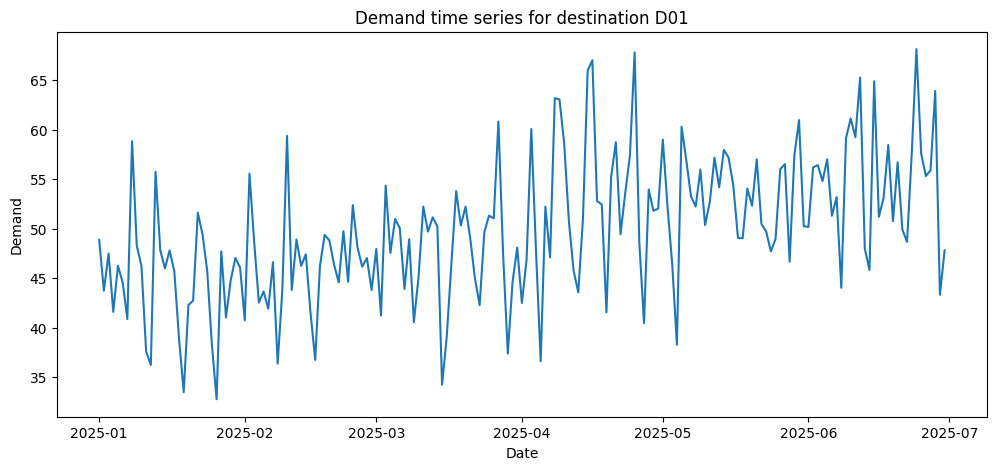

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(demand_d1['date'], demand_d1['demand'])
ax.set_title(f'Demand time series for destination {d1}')
ax.set_xlabel('Date')
ax.set_ylabel('Demand')
plt.show()

We then try to test if the time series are stationary or not. This is important for many powerful model to work (ARIMA, SARIMAX).

We first start with an ADF (Augmented Dickey-Fuller) test and KPSS test. These test try to verify two opposite null hypotheses: the first one tests as null hypothesis if the time series is not stationary, the second one extablishes if there is statistical evidence that the time series is stationary.

In [12]:
from statsmodels.tsa.stattools import kpss, adfuller

def kpss_test(timeseries, alpha=0.05):
    statistic, p_value, *_ = kpss(
        timeseries,
        regression="c",
        nlags="auto"
    )

    if p_value < alpha:
        print(
            f"KPSS: The series is NOT stationary "
            f"(p-value={p_value:.4f} < alpha={alpha})"
        )
    else:
        print(
            f"KPSS: The series is stationary "
            f"(p-value={p_value:.4f} >= alpha={alpha})"
        )


def adf_test(timeseries, alpha=0.05):
    statistic, p_value, *_ = adfuller(
        timeseries,
        autolag="AIC"
    )

    if p_value < alpha:
        print(
            f"ADF: The series is stationary "
            f"(p-value={p_value:.4f} < alpha={alpha})"
        )
    else:
        print(
            f"ADF: The series is NOT stationary "
            f"(p-value={p_value:.4f} >= alpha={alpha})"
        )


# Example
kpss_test(demand_d1["demand"])
adf_test(demand_d1["demand"])

KPSS: The series is NOT stationary (p-value=0.0100 < alpha=0.05)
ADF: The series is NOT stationary (p-value=0.6326 >= alpha=0.05)


/var/folders/nq/dq5yk89j5gvcqg33gk283gkh0000gq/T/ipykernel_13910/2118185332.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, *_ = kpss(


We do not have statistical evidence from either the ADF or KPSS tests to conclude that the time series is stationary.

For the ADF test, the p-value is high, therefore we fail to reject the null hypothesis that the time series is non-stationary.
For the KPSS test, the p-value is smaller than 0.05, therefore we reject the null hypothesis that the time series is stationary.

Both tests suggest that the time series is non-stationary.